In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

In [2]:
# Load datasets
sales = pd.read_csv("sales_data.csv")
customers = pd.read_csv("customer_churn.csv")

# Display first rows
sales.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [3]:
customers.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [4]:
# Check dataset structure
sales.info()

customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   P

In [5]:
sales.isnull().sum()
customers.isnull().sum()

CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

In [6]:
sales.describe()

,Quantity,Price,Total_Sales
count,100.000000,100.000000,100.000000
mean,4.780000,25808.510000,123650.480000
std,2.588163,13917.630242,100161.085275
min,1.000000,1308.000000,6540.000000
25%,2.750000,14965.250000,39517.500000
50%,5.000000,24192.000000,97955.500000
75%,7.000000,38682.250000,175792.500000
max,9.000000,49930.000000,373932.000000


In [7]:
# Convert date column
sales['Date'] = pd.to_datetime(sales['Date'])

In [8]:
sales['Year'] = sales['Date'].dt.year
sales['Month'] = sales['Date'].dt.month
sales['Day'] = sales['Date'].dt.day

sales.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Year,Month,Day
0,2024-01-01,Phone,7,37300,CUST001,East,261100,2024,1,1
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,2024,1,2
2,2024-01-03,Phone,2,21746,CUST003,West,43492,2024,1,3
3,2024-01-04,Headphones,1,30895,CUST004,East,30895,2024,1,4
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,2024,1,5


In [9]:
top_customers = sales.groupby("Customer_ID")["Total_Sales"].sum().sort_values(ascending=False)

top_customers.head(10)

Customer_ID
CUST016    373932
CUST007    363870
CUST083    350888
CUST073    349510
CUST020    333992
CUST084    324144
CUST070    318762
CUST005    318680
CUST065    312564
CUST028    304465
Name: Total_Sales, dtype: int64

In [10]:
customer_value = sales.groupby("Customer_ID").agg({
    "Total_Sales": "sum",
    "Quantity": "sum"
})

customer_value.rename(columns={
    "Total_Sales": "Lifetime_Value",
    "Quantity": "Total_Items"
}, inplace=True)

customer_value.head()

,Lifetime_Value,Total_Items
Customer_ID,,
CUST001,261100,7
CUST002,61624,4
CUST003,43492,2
CUST004,30895,1
CUST005,318680,8


In [11]:
region_sales = sales.groupby("Region")["Total_Sales"].sum()

region_sales

Region
East     2519639
North    3983635
South    3737852
West     2123922
Name: Total_Sales, dtype: int64

In [12]:
monthly_sales = sales.groupby("Month")["Total_Sales"].sum()

monthly_sales

Month
1    4120524
2    2656050
3    4485006
4    1103468
Name: Total_Sales, dtype: int64

In [13]:
product_sales = sales.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False)

product_sales

Product
Laptop        3889210
Tablet        2884340
Phone         2859394
Headphones    1384033
Monitor       1348071
Name: Total_Sales, dtype: int64

In [14]:
avg_price = sales.groupby("Product")["Price"].mean()

avg_price

Product
Headphones    28692.133333
Laptop        27651.500000
Monitor       20709.666667
Phone         27379.000000
Tablet        24177.230769
Name: Price, dtype: float64

In [15]:
quantity_sales = sales.groupby("Product")["Quantity"].sum()

quantity_sales

Product
Headphones     48
Laptop        136
Monitor        66
Phone         101
Tablet        127
Name: Quantity, dtype: int64

In [16]:
filtered_sales = sales[(sales["Product"] == "Laptop") & (sales["Region"] == "North")]

filtered_sales.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Year,Month,Day
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,2024,1,5
19,2024-01-20,Laptop,8,41749,CUST020,North,333992,2024,1,20
22,2024-01-23,Laptop,9,29275,CUST023,North,263475,2024,1,23
25,2024-01-26,Laptop,3,25948,CUST026,North,77844,2024,1,26
65,2024-03-06,Laptop,8,14381,CUST066,North,115048,2024,3,6


In [17]:
sales[(sales["Region"] == "North") | (sales["Region"] == "East")].head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Year,Month,Day
0,2024-01-01,Phone,7,37300,CUST001,East,261100,2024,1,1
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,2024,1,2
3,2024-01-04,Headphones,1,30895,CUST004,East,30895,2024,1,4
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,2024,1,5
8,2024-01-09,Tablet,3,32791,CUST009,North,98373,2024,1,9


In [18]:
# Convert product names to lowercase
sales["Product"] = sales["Product"].str.lower()

# Filter products containing 'phone'
sales[sales["Product"].str.contains("phone")]

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Year,Month,Day
0,2024-01-01,phone,7,37300,CUST001,East,261100,2024,1,1
1,2024-01-02,headphones,4,15406,CUST002,North,61624,2024,1,2
2,2024-01-03,phone,2,21746,CUST003,West,43492,2024,1,3
3,2024-01-04,headphones,1,30895,CUST004,East,30895,2024,1,4
11,2024-01-12,phone,2,13233,CUST012,West,26466,2024,1,12
12,2024-01-13,phone,8,20655,CUST013,East,165240,2024,1,13
13,2024-01-14,headphones,4,4195,CUST014,East,16780,2024,1,14
14,2024-01-15,headphones,2,34447,CUST015,West,68894,2024,1,15
15,2024-01-16,phone,9,41548,CUST016,South,373932,2024,1,16
16,2024-01-17,phone,5,13488,CUST017,South,67440,2024,1,17


In [19]:
merged_data = pd.merge(
    sales,
    customers,
    left_on="Customer_ID",
    right_on="CustomerID",
    how="left"
)

merged_data.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Year,Month,Day,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,2024-01-01,phone,7,37300,CUST001,East,261100,2024,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-02,headphones,4,15406,CUST002,North,61624,2024,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01-03,phone,2,21746,CUST003,West,43492,2024,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-04,headphones,1,30895,CUST004,East,30895,2024,1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-05,laptop,8,39835,CUST005,North,318680,2024,1,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
pivot_table = pd.pivot_table(
    sales,
    values="Total_Sales",
    index="Region",
    columns="Product",
    aggfunc="sum"
)

pivot_table

Product,headphones,laptop,monitor,phone,tablet
Region,,,,,
East,288361,221946,642870,506828,859634
North,107091,1798206,397100,489284,1191954
South,512168,1373120,39924,1471428,341212
West,476413,495938,268177,391854,491540


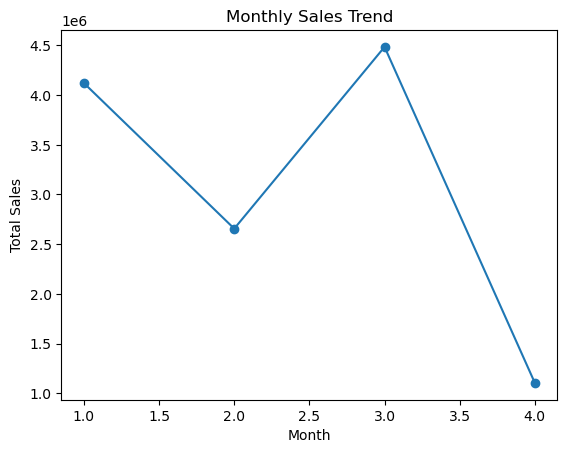

In [21]:
monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

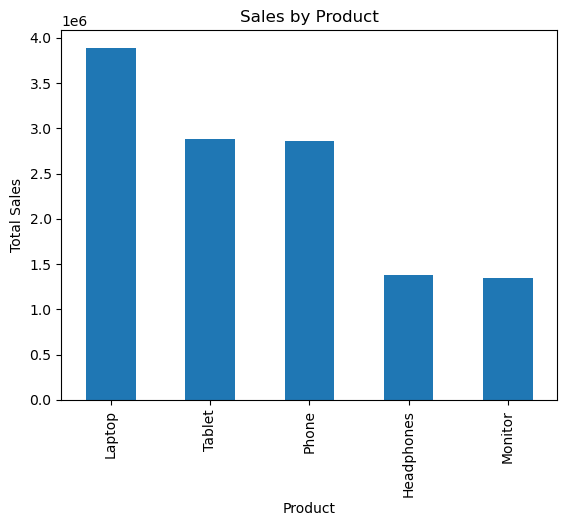

In [22]:
product_sales.plot(kind='bar')

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.show()

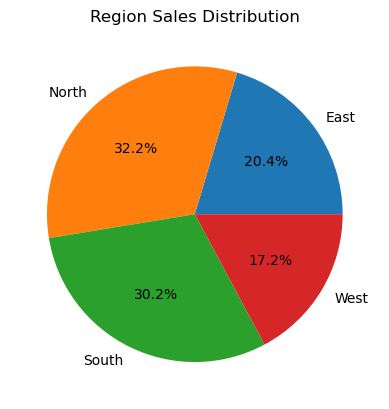

In [23]:
region_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title("Region Sales Distribution")
plt.ylabel("")
plt.show()

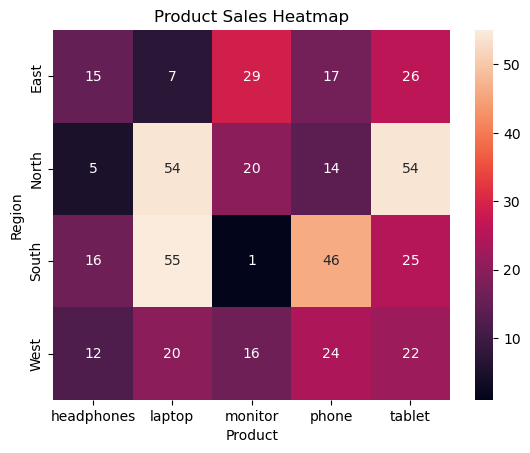

In [24]:
heatmap_data = sales.pivot_table(
    values='Quantity',
    index='Region',
    columns='Product',
    aggfunc='sum'
)

sns.heatmap(heatmap_data, annot=True)

plt.title("Product Sales Heatmap")
plt.show()

In [25]:
total_revenue = sales["Total_Sales"].sum()
total_customers = sales["Customer_ID"].nunique()
avg_order_value = sales["Total_Sales"].mean()

print("Total Revenue:", total_revenue)
print("Total Customers:", total_customers)
print("Average Order Value:", avg_order_value)

Total Revenue: 12365048
Total Customers: 100
Average Order Value: 123650.48
